**MCP Tool**

- Function tool은 “내 앱 코드 안에 직접 등록한 함수”이고, MCP tool은 “외부 MCP 서버가 제공하는 도구들을 표준 프로토콜로 연결한 것”입니다.

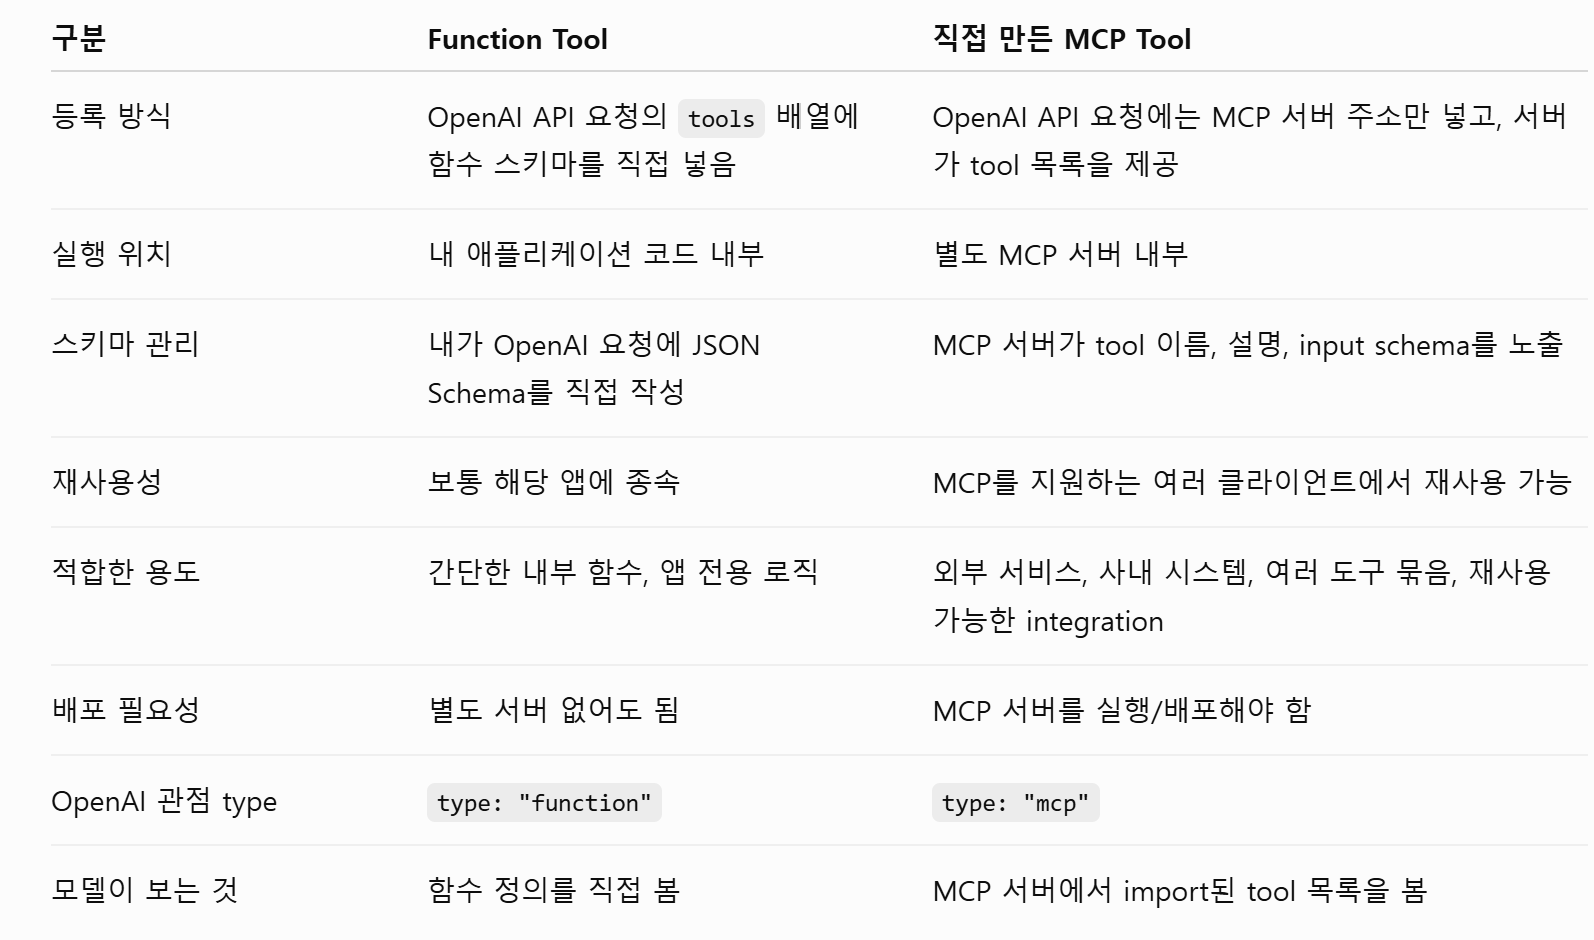

In [4]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4o-mini",
    input="서울의 현재 날씨와 대기질을 간단히 알려줘. 현재 비 올 가능성도 알려줘",
    tools=[
        {
            "type": "mcp",
            "server_label": "korea_weather",
            "server_url": "https://mcp.open-mcp.org/api/server/korea-weather@latest/mcp",
            "require_approval": "never",
            "allowed_tools": [
                "tool_get_current_weather_post",
                "tool_get_air_quality_post",
            ],
        }
    ],
)

print(response.output_text)

서울의 현재 날씨와 대기질 정보를 제공하지 못했습니다. 그러나 일반적으로 서울의 날씨는 대체로 맑거나 구름이 많은 상태이며, 비의 가능성도 계절에 따라 다소 다릅니다.

대기질은 보통 대기 오염이 심한 날과 좋은 날이 교차하므로, 특정 일자에 따라 달라질 수 있습니다. 비올 가능성은 일기 예보를 참고하시는 것이 좋습니다.

정확한 정보를 원하신다면 최신 기상 웹사이트나 어플리케이션을 확인해주시는 것을 추천합니다.


---

## **ReAct 루프**

**ReAct: Synergizing Reasoning and Acting in Language Models** 
(언어 모델에서의 추론과 행동의 시너지 창출)
- 2023년 ICLR(International Conference on Learning Representations)에 발표된 논문

- LLM이 **생각하기(Thought)** 와 **행동하기(Action)** 를 번갈아 하면서, 행동의 결과(Observation)를 다시 다음 생각에 반영합니다. 
- 이 세 가지가 한 사이클을 이루고, 모델은 매 사이클마다 "이미 관찰한 사실"을 근거로 다음 판단을 갱신합니다.

**다른 패러다임과 비교**

- Chain-of-Thought: 추론만 하고 외부 세계와 상호작용이 없습니다. 틀린 가정을 검증할 방법이 없어 환각에 취약합니다.
- Act-only: 추론 과정 없이 바로 도구를 호출합니다. 왜 그 도구를 골랐는지 설명이 안 되고, 복잡한 다단계 문제에서 방향을 잃기 쉽습니다.
- Plan-and-Execute: 처음에 전체 계획을 세우고 그대로 밀어붙입니다. 중간에 예상 못한 정보(예: "어 비가 오네")가 나와도 계획을 수정하기 어렵습니다.
- ReAct: 매 단계마다 관찰 결과를 보고 생각을 다시 합니다. 동적으로 계획을 바꿀 수 있어 환각이 줄어듭니다.

In [ ]:
"""react_minimal.py - ReAct 루프의 본질만 남긴 최소 예제"""
import json
from openai import OpenAI
import random

client = OpenAI()


def calculator(expression: str) -> str:
    """사칙연산 계산기 (학습용 eval → 실제 서비스에선 안전한 파서 권장)"""
    return str(eval(expression)) if random.randint(1, 3) == 1 else ""


tools = [{
    "type": "function",
    "name": "calculator",
    "description": "사칙연산 수식을 계산합니다.",
    "parameters": {
        "type": "object",
        "properties": {"expression": {"type": "string"}},
        "required": ["expression"],
    },
}]


def run(question: str):
    messages = [{"role": "user", "content": question}]

    for _ in range(5):  # 최대 5번 반복 (무한루프 방지)
        # ① 메시지 + 도구 목록을 모델에 보낸다
        response = client.responses.create(
            model="gpt-4o-mini",
            tools=tools,
            input=messages,
        )
        messages += response.output

        calls = [item for item in response.output if item.type == "function_call"]

        if not calls:                       # 도구 요청이 없다 = 최종 답변
            return response.output_text

        # ② 도구 호출 요청을 실행하고 결과를 다시 넣는다
        for call in calls:
            args = json.loads(call.arguments)
            result = calculator(**args)
            print(f"tool: {call.name}({args}) -> {result}")

            messages.append({
                "type": "function_call_output",
                "call_id": call.call_id,
                "output": result,
            })

    return "최대 반복 횟수를 초과했습니다."

In [ ]:
answer = run("153 곱하기 27은 얼마야? 계산기로 정확히 확인해줘.")
print("최종 답변:", answer)

In [ ]:
answer = run("1에 2를 더하고 이 결과에 4를 곱하면 얼마야? 계산기로 정확히 확인해줘.")
print("최종 답변:", answer)

----

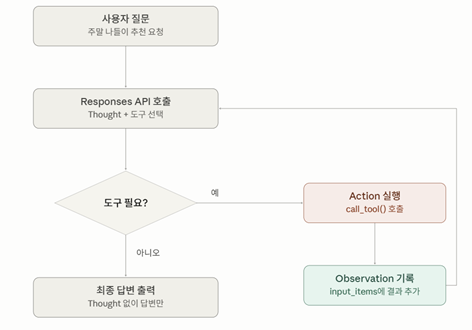

In [ ]:
from openai import OpenAI
import json

MODEL = "gpt-4o-mini"
client = OpenAI()


# ------------------------------------------------------------
# 1. Toy Database
# ------------------------------------------------------------
# 외부 API를 쓰지 않고도 ReAct 흐름을 연습할 수 있도록
# 날씨, 장소, 비용 정보를 코드 안에 작게 넣어둡니다.

WEATHER_DB = {
    ("서울", "토요일"): {
        "condition": "비",
        "temperature_c": 24,
        "summary": "오후에 비가 올 가능성이 높습니다. 실내 활동을 추천합니다.",
    },
    ("서울", "일요일"): {
        "condition": "맑음",
        "temperature_c": 28,
        "summary": "대체로 맑고 야외 활동하기 좋습니다.",
    },
    ("부산", "토요일"): {
        "condition": "흐림",
        "temperature_c": 25,
        "summary": "흐리지만 비 가능성은 낮습니다.",
    },
}

PLACE_DB = [
    {
        "city": "서울",
        "name": "국립중앙박물관",
        "type": "문화",
        "indoor": True,
        "price_per_person": 0,
        "duration_hours": 2.5,
        "description": "비 오는 날에도 편하게 볼 수 있는 대형 실내 전시 공간입니다.",
    },
    {
        "city": "서울",
        "name": "성수동 카페거리",
        "type": "카페",
        "indoor": True,
        "price_per_person": 15000,
        "duration_hours": 2,
        "description": "카페와 편집숍을 함께 둘러보기 좋습니다.",
    },
    {
        "city": "서울",
        "name": "잠실 롯데월드몰",
        "type": "쇼핑",
        "indoor": True,
        "price_per_person": 20000,
        "duration_hours": 3,
        "description": "쇼핑, 식사, 전시를 한 번에 해결할 수 있는 실내 코스입니다.",
    },
    {
        "city": "서울",
        "name": "서울숲",
        "type": "산책",
        "indoor": False,
        "price_per_person": 0,
        "duration_hours": 2,
        "description": "날씨가 좋을 때 산책하기 좋은 야외 공간입니다.",
    },
    {
        "city": "서울",
        "name": "한강공원",
        "type": "산책",
        "indoor": False,
        "price_per_person": 10000,
        "duration_hours": 2,
        "description": "돗자리, 간식, 자전거 등을 즐길 수 있는 야외 코스입니다.",
    },
]


# ------------------------------------------------------------
# 2. Real Python Tools
# ------------------------------------------------------------
# 모델이 직접 실행하는 것이 아니라,
# 모델이 "이 함수를 호출해줘"라고 요청하면
# 우리가 Python 코드에서 실행해주는 구조입니다.

def get_weather(city: str, day: str) -> dict:
    """도시와 요일에 대한 날씨 정보를 가져옵니다."""
    result = WEATHER_DB.get((city, day))
    if result is None:
        return {
            "city": city,
            "day": day,
            "error": "해당 도시/요일의 날씨 정보가 없습니다.",
        }

    return {
        "city": city,
        "day": day,
        **result,
    }


def search_places(city: str, indoor_required: bool, preference: str) -> dict:
    """조건에 맞는 장소 후보를 검색합니다."""
    candidates = []

    for place in PLACE_DB:
        if place["city"] != city:
            continue

        if indoor_required and not place["indoor"]:
            continue

        # preference는 너무 엄격하게 필터링하지 않고,
        # 타입 또는 설명에 포함되면 점수를 조금 높이는 방식으로 씁니다.
        score = 0
        if preference in place["type"]:
            score += 2
        if preference in place["description"]:
            score += 1
        if place["indoor"]:
            score += 1

        candidates.append({
            **place,
            "match_score": score,
        })

    candidates.sort(key=lambda x: x["match_score"], reverse=True)

    return {
        "city": city,
        "indoor_required": indoor_required,
        "preference": preference,
        "places": candidates[:5],
    }


def estimate_total_cost(place_name: str, people: int) -> dict:
    """장소 이름과 인원수를 기반으로 총 예상 비용을 계산합니다."""
    for place in PLACE_DB:
        if place["name"] == place_name:
            total = place["price_per_person"] * people
            return {
                "place_name": place_name,
                "people": people,
                "price_per_person": place["price_per_person"],
                "total_cost": total,
                "currency": "KRW",
            }

    return {
        "place_name": place_name,
        "error": "장소를 찾을 수 없습니다.",
    }


# ------------------------------------------------------------
# 3. Tool Schemas for Responses API
# ------------------------------------------------------------
# Responses API의 function calling에서는 tools에 함수 스키마를 넣습니다.
# strict=True를 쓰려면 모든 properties를 required에 넣고,
# additionalProperties=False를 지정하는 것이 좋습니다.

TOOLS = [
    {
        "type": "function",
        "name": "get_weather",
        "description": "도시와 요일을 입력받아 날씨를 확인합니다. 비가 오는지 판단할 때 사용합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "도시 이름. 예: 서울, 부산",
                },
                "day": {
                    "type": "string",
                    "description": "요일. 예: 토요일, 일요일",
                },
            },
            "required": ["city", "day"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "search_places",
        "description": "도시, 실내 필요 여부, 선호 활동을 기준으로 장소 후보를 찾습니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "city": {
                    "type": "string",
                    "description": "도시 이름. 예: 서울",
                },
                "indoor_required": {
                    "type": "boolean",
                    "description": "비가 오거나 실내 활동이 필요하면 true",
                },
                "preference": {
                    "type": "string",
                    "description": "선호 활동. 예: 문화, 카페, 쇼핑, 산책",
                },
            },
            "required": ["city", "indoor_required", "preference"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "estimate_total_cost",
        "description": "장소 이름과 인원수를 입력받아 총 예상 비용을 계산합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "place_name": {
                    "type": "string",
                    "description": "장소 이름",
                },
                "people": {
                    "type": "integer",
                    "description": "방문 인원수",
                },
            },
            "required": ["place_name", "people"],
            "additionalProperties": False,
        },
    },
]


# ------------------------------------------------------------
# 4. Tool Dispatcher
# ------------------------------------------------------------

def call_tool(name: str, args: dict) -> dict:
    """모델이 요청한 tool name을 실제 Python 함수에 연결합니다."""
    if name == "get_weather":
        return get_weather(**args)

    if name == "search_places":
        return search_places(**args)

    if name == "estimate_total_cost":
        return estimate_total_cost(**args)

    return {
        "error": f"Unknown tool: {name}",
    }


# ------------------------------------------------------------
# 5. ReAct Agent Loop  (Thought 출력이 추가된 버전)
# ------------------------------------------------------------
# 이론적 ReAct 사이클 그대로:
#
#   Thought      -> 다음에 뭘 할지 추론 (이 버전에서는 콘솔에 직접 출력됨)
#   Action       -> function_call 실행
#   Observation  -> 실행 결과 관찰
#   (반복) -> 더 필요한 정보가 없으면 최종 답변
#
# [보완한 부분]
# - INSTRUCTIONS에 "행동 전에 Thought: 한 줄을 반드시 남긴다"는 규칙을 추가했습니다.
# - Responses API에서 같은 턴에 (자연어 메시지 + function_call)이 함께 오면,
#   response.output_text에는 메시지 쪽 텍스트만 모여서 돌아옵니다.
#   즉 function_call이 있는 턴의 output_text == 모델이 남긴 Thought 문장이 됩니다.
# - 최종 답변 턴(= function_call이 없는 턴)에는 Thought가 따로 없으므로,
#   분기를 먼저 나눠서 Thought와 최종 답변이 중복 출력되지 않게 했습니다.

INSTRUCTIONS = """
너는 ReAct 스타일의 주말 나들이 추천 에이전트다.

목표:
- 사용자의 요청을 해결하기 위해 필요한 정보를 직접 추측하지 말고 도구로 확인한다.
- 날씨가 조건에 영향을 주면 반드시 get_weather를 먼저 사용한다.
- 장소 후보가 필요하면 search_places를 사용한다.
- 비용/예산 판단이 필요하면 estimate_total_cost를 사용한다.
- 도구 호출은 한 번에 하나씩만 한다.
- 최종 답변은 한국어로 작성한다.

중요 — Thought 규칙:
- 도구를 호출하기 전에 반드시 "Thought: "로 시작하는 한 문장을 먼저 작성한다.
  예: "Thought: 토요일 날씨를 먼저 확인해야 실내/야외 여부를 판단할 수 있다."
- 더 이상 도구가 필요 없어 최종 답변을 낼 때는 Thought 문장 없이 최종 답변 형식만 작성한다.

최종 답변 형식:
1. 추천 장소
2. 추천 이유
3. 날씨 고려
4. 예상 비용
5. 예산 충족 여부
6. 대안 후보
"""


def run_react_agent(user_question: str, max_steps: int = 8) -> str:
    input_items = [
        {
            "role": "user",
            "content": user_question,
        }
    ]

    for step in range(1, max_steps + 1):
        print(f"\n========== STEP {step} ==========")

        response = client.responses.create(
            model=MODEL,
            instructions=INSTRUCTIONS,
            input=input_items,
            tools=TOOLS,
            temperature=0.2,
            tool_choice="auto",
            # 초보자 학습용이므로 한 번에 하나의 도구만 호출하게 합니다.
            # ReAct 흐름을 보기 훨씬 쉽습니다.
            parallel_tool_calls=False,
        )

        # 다음 턴에 모델의 직전 출력도 같이 넘겨야 합니다.
        input_items += response.output

        function_calls = [
            item for item in response.output
            if getattr(item, "type", None) == "function_call"
        ]

        # 더 이상 tool call이 없으면 최종 답변입니다.
        # (이 턴에는 Thought가 따로 없으므로 바로 최종 답변만 출력합니다.)
        if not function_calls:
            print("\n========== FINAL ANSWER ==========")
            print(response.output_text)
            return response.output_text

        # [보완된 부분] Thought 출력
        # function_call이 있는 턴에 모델이 같이 남긴 "Thought: ..." 문장을 보여줍니다.
        thought_text = response.output_text.strip()
        if thought_text:
            print(f"[Thought] {thought_text}")

        # parallel_tool_calls=False라 보통 하나만 오지만,
        # 안전하게 여러 개도 처리 가능하게 둡니다.
        for function_call in function_calls:
            tool_name = function_call.name
            tool_args = json.loads(function_call.arguments)

            print(f"[Action] {tool_name}")
            print(f"[Action Input] {json.dumps(tool_args, ensure_ascii=False, indent=2)}")

            tool_result = call_tool(tool_name, tool_args)

            print("[Observation]")
            print(json.dumps(tool_result, ensure_ascii=False, indent=2))

            input_items.append({
                "type": "function_call_output",
                "call_id": function_call.call_id,
                "output": json.dumps(tool_result, ensure_ascii=False),
            })

    raise RuntimeError("최대 step 수를 초과했습니다. 도구 루프가 끝나지 않았습니다.")


# ------------------------------------------------------------
# 6. Test
# ------------------------------------------------------------

if __name__ == "__main__":
    question = """
    이번 토요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘.
    비가 오면 실내였으면 좋겠고, 전체 예산은 6만원 이하였으면 해.
    나는 문화/전시 쪽을 선호해.
    """

    run_react_agent(question)

In [ ]:
run_react_agent("이번 일요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘. ")

In [ ]:
run_react_agent("이번 일요일에 서울에서 친구랑 2명이 갈 만한 곳 추천해줘. 근데 예산이 좀 부족해... 둘이서 10000원으로 즐길 수 있는 곳을 추천해줘")

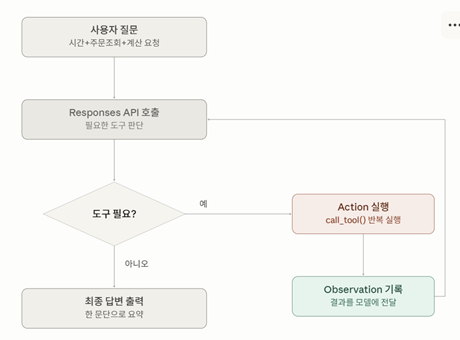

In [ ]:
"""
목적:
    "도구 결과가 원하는 결과가 아니면 다시 시도하는 ReAct 루프"를 확인하는 최소 예제입니다.

핵심 시나리오:
    사용자: "7명 회의실 예약해줘. 먼저 Alpha 회의실로 시도해."
    1) 모델이 reserve_room("Alpha") 호출
    2) 도구 결과: Alpha는 unavailable
    3) 모델이 실패 Observation을 보고 search_available_rooms 호출
    4) 모델이 대체 회의실 Beta를 골라 reserve_room("Beta") 재호출
    5) 도구 결과: success
    6) 모델이 최종 답변
"""

from __future__ import annotations

import json
import os
from typing import Any

from dotenv import load_dotenv
from openai import OpenAI


# ---------------------------------------------------------------------
# 1. 가짜 회의실 DB
# ---------------------------------------------------------------------

ROOM_DB = {
    "Alpha": {
        "capacity": 10,
        "available": False,
        "reason": "이미 예약되어 있습니다.",
    },
    "Beta": {
        "capacity": 8,
        "available": True,
        "reason": None,
    },
    "Gamma": {
        "capacity": 4,
        "available": True,
        "reason": None,
    },
    "Delta": {
        "capacity": 12,
        "available": True,
        "reason": None,
    },
}


# ---------------------------------------------------------------------
# 2. 로컬 도구 함수
# ---------------------------------------------------------------------

def reserve_room(room_name: str, date: str, start_time: str, duration_minutes: int, people: int) -> dict[str, Any]:
    """
    회의실 예약을 시도합니다.
    성공하면 success=True, 실패하면 success=False를 반환합니다.
    """

    room = ROOM_DB.get(room_name)

    if room is None:
        return {
            "success": False,
            "room_name": room_name,
            "status": "not_found",
            "message": "존재하지 않는 회의실입니다.",
        }

    if room["capacity"] < people:
        return {
            "success": False,
            "room_name": room_name,
            "status": "too_small",
            "capacity": room["capacity"],
            "people": people,
            "message": f"{people}명을 수용하기에는 회의실이 작습니다.",
        }

    if not room["available"]:
        return {
            "success": False,
            "room_name": room_name,
            "status": "unavailable",
            "message": room["reason"],
        }

    return {
        "success": True,
        "room_name": room_name,
        "status": "reserved",
        "date": date,
        "start_time": start_time,
        "duration_minutes": duration_minutes,
        "people": people,
        "message": "예약이 완료되었습니다.",
    }


def search_available_rooms(date: str, start_time: str, duration_minutes: int, people: int) -> dict[str, Any]:
    """
    조건에 맞는 대체 회의실을 검색합니다.
    """

    candidates = []

    for room_name, room in ROOM_DB.items():
        if room["available"] and room["capacity"] >= people:
            candidates.append(
                {
                    "room_name": room_name,
                    "capacity": room["capacity"],
                }
            )

    return {
        "date": date,
        "start_time": start_time,
        "duration_minutes": duration_minutes,
        "people": people,
        "candidates": candidates,
    }


# ---------------------------------------------------------------------
# 3. OpenAI에 전달할 Tool Schema
# ---------------------------------------------------------------------

TOOLS = [
    {
        "type": "function",
        "name": "reserve_room",
        "description": "지정한 회의실을 예약합니다. 예약 실패 시 실패 이유를 반환합니다.",
        "parameters": {
            "type": "object",
            "properties": {
                "room_name": {
                    "type": "string",
                    "description": "예약할 회의실 이름. 예: Alpha, Beta, Gamma, Delta",
                },
                "date": {
                    "type": "string",
                    "description": "예약 날짜. 예: 2026-07-01",
                },
                "start_time": {
                    "type": "string",
                    "description": "시작 시간. 예: 10:00",
                },
                "duration_minutes": {
                    "type": "integer",
                    "description": "회의 시간. 단위: 분",
                },
                "people": {
                    "type": "integer",
                    "description": "참석 인원 수",
                },
            },
            "required": ["room_name", "date", "start_time", "duration_minutes", "people"],
            "additionalProperties": False,
        },
        "strict": True,
    },
    {
        "type": "function",
        "name": "search_available_rooms",
        "description": "조건에 맞는 예약 가능한 회의실 후보를 검색합니다.",
        "parameters": {
            "type": "object",
            "properties": {
                "date": {
                    "type": "string",
                    "description": "예약 날짜. 예: 2026-07-01",
                },
                "start_time": {
                    "type": "string",
                    "description": "시작 시간. 예: 10:00",
                },
                "duration_minutes": {
                    "type": "integer",
                    "description": "회의 시간. 단위: 분",
                },
                "people": {
                    "type": "integer",
                    "description": "참석 인원 수",
                },
            },
            "required": ["date", "start_time", "duration_minutes", "people"],
            "additionalProperties": False,
        },
        "strict": True,
    },
]


# ---------------------------------------------------------------------
# 4. 모델이 요청한 tool name을 실제 파이썬 함수로 연결
# ---------------------------------------------------------------------

def call_tool(name: str, arguments: dict[str, Any]) -> dict[str, Any]:
    if name == "reserve_room":
        return reserve_room(**arguments)

    if name == "search_available_rooms":
        return search_available_rooms(**arguments)

    return {
        "success": False,
        "error": f"알 수 없는 도구입니다: {name}",
    }


# ---------------------------------------------------------------------
# 5. ReAct 반복 루프
# ---------------------------------------------------------------------

def run_react_retry(user_prompt: str, max_steps: int = 6) -> str:
    load_dotenv()

    client = OpenAI()
    model = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

    input_items: list[Any] = [
        {
            "role": "user",
            "content": user_prompt,
        }
    ]

    print("\n==============================")
    print("ReAct retry loop check start")
    print("==============================")
    print(f"model: {model}")
    print(f"user: {user_prompt}")

    for step in range(1, max_steps + 1):
        print(f"\n--- STEP {step}: model thinking/action ---")

        response = client.responses.create(
            model=model,
            instructions=(
                "너는 회의실 예약 에이전트다. "
                "반드시 도구를 사용해서 예약을 시도해야 한다. "
                "처음 요청한 회의실 예약에 실패하면, 실패했다고 바로 끝내지 말고 "
                "예약 가능한 대체 회의실을 검색한 뒤 다시 예약을 시도하라. "
                "예약 성공 Observation을 받은 뒤에만 최종 답변하라. "
                "최종 답변은 한국어로 짧게 작성하라."
            ),
            tools=TOOLS,
            input=input_items,
        )

        # 모델의 이번 출력 기록을 다음 입력에 유지합니다.
        # 여기에는 function_call도 포함됩니다.
        input_items += response.output

        function_calls = [
            item for item in response.output
            if getattr(item, "type", None) == "function_call"
        ]

        # function_call이 없으면 모델이 최종 답변을 낸 것입니다.
        if not function_calls:
            final_text = response.output_text or ""
            print("\n--- FINAL ANSWER ---")
            print(final_text)
            return final_text

        # 모델이 요청한 tool call들을 실행합니다.
        for call in function_calls:
            tool_name = call.name
            tool_args = json.loads(call.arguments)

            print(f"\nAction: {tool_name}")
            print(f"Arguments: {json.dumps(tool_args, ensure_ascii=False)}")

            tool_result = call_tool(tool_name, tool_args)

            print(f"Observation: {json.dumps(tool_result, ensure_ascii=False)}")

            # 실행 결과를 다시 모델에게 전달합니다.
            # call_id로 어떤 function_call의 결과인지 연결됩니다.
            input_items.append(
                {
                    "type": "function_call_output",
                    "call_id": call.call_id,
                    "output": json.dumps(tool_result, ensure_ascii=False),
                }
            )

    raise RuntimeError(f"max_steps={max_steps} 안에 완료하지 못했습니다.")


if __name__ == "__main__":
    prompt = (
        "2026-07-01 10:00에 7명 회의를 60분 동안 예약해줘. "
        "먼저 Alpha 회의실로 예약을 시도해줘. "
        "Alpha가 안 되면 가능한 다른 회의실을 찾아서 다시 예약해줘."
    )

    run_react_retry(prompt)


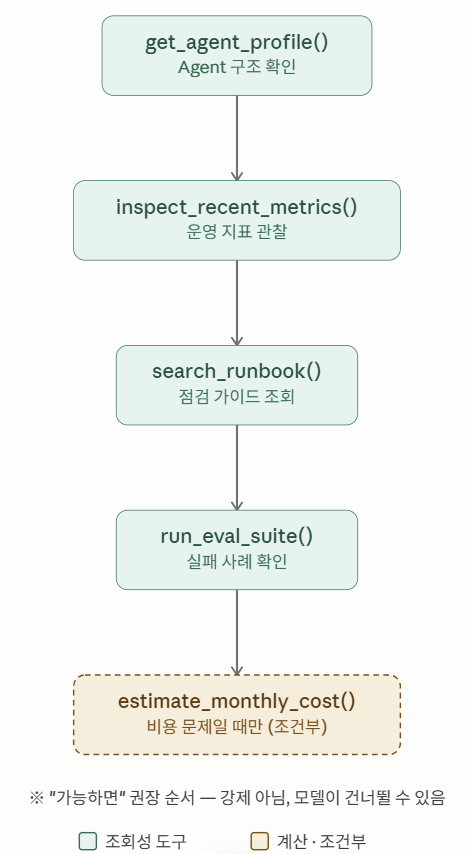

In [ ]:
"""
A slightly more advanced ReAct-style AI Agent troubleshooting demo.

Theme:
    "AI Agent 운영/개선 코치"
    - RAG 정확도 저하
    - 외부 툴/API 실패
    - 비용/지연시간 증가
    - 데모 전 릴리즈 리스크 점검

Goal:
    ReAct의 흐름을 초보자도 눈으로 확인할 수 있게 만든 순수 Python 예제입니다.

    추론 요약(Reason) -> 도구 호출(Act) -> 결과 관찰(Observe) -> 다음 판단

Requirements:
    pip install openai

Run:
    python react_agent_advanced.py
    python react_agent_advanced.py --scenario accuracy
    python react_agent_advanced.py --scenario tool
    python react_agent_advanced.py --scenario cost
    python react_agent_advanced.py --scenario launch
    python react_agent_advanced.py --custom "helpdesk-rag-agent의 답변 정확도가 요즘 떨어졌어. 원인과 개선안을 알려줘."

Notes:
    - 외부 프레임워크를 사용하지 않습니다.
    - 실제 외부 DB/API도 사용하지 않습니다.
    - tools는 모두 이 파일 안의 Python 함수입니다.
    - OpenAI Responses API의 client.responses.create()를 사용합니다.
    - function_call 결과는 function_call_output으로 돌려줍니다.
    - previous_response_id를 사용해 이전 응답 상태를 이어갑니다.
"""

from __future__ import annotations

import argparse
import json
import os
import textwrap
from typing import Any, Callable

from openai import OpenAI


MODEL = "gpt-4o-mini"


# =============================================================================
# 1. Toy Data: AI Agent 운영 상황을 흉내 내는 작은 DB
# =============================================================================

AGENT_PROFILES: dict[str, dict[str, Any]] = {
    "helpdesk-rag-agent": {
        "name": "helpdesk-rag-agent",
        "purpose": "고객지원 문서를 검색해서 답변하는 RAG 기반 상담 에이전트",
        "model": "gpt-4o-mini",
        "tools": ["retrieve_policy_docs", "create_support_ticket"],
        "retrieval": {
            "top_k": 3,
            "chunk_size": 900,
            "reranker": False,
            "citation_required": True,
            "doc_freshness_days": 90,
        },
        "guardrails": {
            "must_cite_sources": True,
            "ask_when_low_confidence": True,
            "min_retrieval_score": 0.72,
        },
    },
    "calendar-agent": {
        "name": "calendar-agent",
        "purpose": "사용자의 일정을 확인하고 회의 일정을 생성하는 예약 에이전트",
        "model": "gpt-4o-mini",
        "tools": ["read_calendar", "create_calendar_event", "send_confirmation_email"],
        "tooling": {
            "requires_timezone": True,
            "requires_human_confirmation": True,
            "retry_count": 1,
        },
        "guardrails": {
            "never_book_without_confirmation": True,
            "detect_timezone_ambiguity": True,
        },
    },
    "research-assistant-agent": {
        "name": "research-assistant-agent",
        "purpose": "논문/문서 요약, 비교표 작성, 아이디어 브레인스토밍을 돕는 연구 보조 에이전트",
        "model": "gpt-4o-mini",
        "tools": ["search_notes", "summarize_paper", "make_comparison_table"],
        "context_policy": {
            "max_files_per_run": 12,
            "summarize_old_context": False,
            "reuse_cached_summary": False,
        },
        "guardrails": {
            "separate_fact_and_opinion": True,
            "cite_when_using_docs": True,
        },
    },
}


RECENT_METRICS: dict[str, dict[str, Any]] = {
    "helpdesk-rag-agent": {
        "window_hours": 24,
        "total_sessions": 1240,
        "avg_latency_ms": 3400,
        "p95_latency_ms": 6800,
        "tool_error_rate": 0.018,
        "retrieval_hit_rate": 0.61,
        "low_confidence_rate": 0.28,
        "answer_escalation_rate": 0.09,
        "suspected_hallucination_rate": 0.16,
        "avg_tokens_per_turn": 1450,
        "notes": [
            "최근 환불 정책 문서가 개정되었지만 일부 청크가 오래된 문서를 가리킴",
            "검색 top_k=3으로 모호한 질문에서 근거 문서 누락 발생",
            "citation_required는 켜져 있으나 min_retrieval_score 미만일 때도 답변하는 케이스가 있음",
        ],
    },
    "calendar-agent": {
        "window_hours": 24,
        "total_sessions": 410,
        "avg_latency_ms": 2100,
        "p95_latency_ms": 4900,
        "tool_error_rate": 0.23,
        "calendar_api_429_count": 72,
        "timezone_missing_rate": 0.17,
        "human_confirmation_skip_rate": 0.04,
        "avg_tokens_per_turn": 780,
        "notes": [
            "외부 캘린더 API rate limit이 오후 시간대에 집중 발생",
            "사용자가 '내일 오전'처럼 말할 때 timezone 값이 누락되는 케이스가 있음",
            "retry_count=1이라 일시적인 429에서 회복률이 낮음",
        ],
    },
    "research-assistant-agent": {
        "window_hours": 24,
        "total_sessions": 190,
        "avg_latency_ms": 9200,
        "p95_latency_ms": 18200,
        "tool_error_rate": 0.026,
        "avg_tokens_per_turn": 7400,
        "long_context_rate": 0.62,
        "duplicate_context_rate": 0.31,
        "cache_hit_rate": 0.08,
        "notes": [
            "이전 대화 요약 재사용이 꺼져 있어 같은 자료를 반복 투입함",
            "문서 12개를 한 번에 넣는 요청이 많아 비용과 지연시간이 증가함",
            "비교표 작성 전 중간 요약을 캐시하지 않음",
        ],
    },
}


RUNBOOKS: dict[str, dict[str, Any]] = {
    "accuracy": {
        "symptom": "accuracy",
        "title": "답변 정확도 또는 환각 문제",
        "recommended_checks": [
            "최근 문서 변경 여부와 인덱스 갱신 여부 확인",
            "retrieval_hit_rate와 low_confidence_rate 확인",
            "검색 top_k, chunk_size, reranker 사용 여부 점검",
            "min_retrieval_score 미만일 때 답변 대신 재질문/에스컬레이션하는지 확인",
            "대표 질문 eval을 실행해 어떤 문서군에서 실패하는지 확인",
        ],
    },
    "tool_error": {
        "symptom": "tool_error",
        "title": "외부 도구/API 실패 문제",
        "recommended_checks": [
            "tool_error_rate와 특정 API 에러 코드 확인",
            "rate limit, 인증, 파라미터 누락 여부 분리",
            "retry/backoff 정책 확인",
            "사용자 확인이 필요한 액션인지 점검",
            "실패 시 안전한 fallback 메시지가 있는지 확인",
        ],
    },
    "cost_latency": {
        "symptom": "cost_latency",
        "title": "비용 또는 지연시간 증가 문제",
        "recommended_checks": [
            "avg_tokens_per_turn, p95_latency_ms 확인",
            "중복 컨텍스트 투입 여부 확인",
            "요약 캐시 또는 이전 결과 재사용 여부 확인",
            "도구 호출 횟수와 불필요한 재검색 여부 확인",
            "큰 모델이 필요한 단계와 작은 모델로 충분한 단계를 분리",
        ],
    },
    "launch_risk": {
        "symptom": "launch_risk",
        "title": "데모/출시 전 리스크 점검",
        "recommended_checks": [
            "정확도, 도구 안정성, 비용/지연시간 eval을 모두 확인",
            "사용자에게 영향을 주는 write action에 확인 절차가 있는지 점검",
            "실패 시 fallback 답변과 에스컬레이션 경로 확인",
            "대표 시나리오 5개 이상으로 end-to-end 테스트",
        ],
    },
}


EVAL_RESULTS: dict[tuple[str, str], dict[str, Any]] = {
    ("helpdesk-rag-agent", "retrieval_quality"): {
        "eval_type": "retrieval_quality",
        "score": 0.68,
        "pass_threshold": 0.80,
        "passed": False,
        "failed_cases": [
            {
                "case": "환불 가능 기간이 바뀐 상품 문의",
                "problem": "오래된 환불 정책 청크가 top-1로 검색됨",
                "suggestion": "문서 freshness metadata를 ranking에 반영",
            },
            {
                "case": "배송 지연 + 환불이 함께 있는 복합 질문",
                "problem": "top_k=3에서 배송 문서만 검색되고 환불 문서가 누락됨",
                "suggestion": "query decomposition 또는 top_k=5~8 테스트",
            },
        ],
    },
    ("helpdesk-rag-agent", "safety_accuracy"): {
        "eval_type": "safety_accuracy",
        "score": 0.74,
        "pass_threshold": 0.85,
        "passed": False,
        "failed_cases": [
            {
                "case": "근거 문서 점수가 낮은 질문",
                "problem": "min_retrieval_score 미만인데도 단정적으로 답변",
                "suggestion": "낮은 검색 점수에서는 재질문 또는 상담원 연결",
            }
        ],
    },
    ("calendar-agent", "tool_reliability"): {
        "eval_type": "tool_reliability",
        "score": 0.71,
        "pass_threshold": 0.90,
        "passed": False,
        "failed_cases": [
            {
                "case": "내일 오전 10시에 미팅 잡아줘",
                "problem": "timezone 파라미터가 누락되어 create_calendar_event 실패",
                "suggestion": "상대 날짜/시간 파싱 후 timezone 기본값 주입",
            },
            {
                "case": "여러 참석자 일정 확인",
                "problem": "429 발생 후 retry 1회로 종료",
                "suggestion": "exponential backoff와 read 요청 batch 처리",
            },
        ],
    },
    ("research-assistant-agent", "cost_latency"): {
        "eval_type": "cost_latency",
        "score": 0.58,
        "pass_threshold": 0.80,
        "passed": False,
        "failed_cases": [
            {
                "case": "논문 10개 비교표 작성",
                "problem": "같은 abstract와 conclusion을 여러 번 컨텍스트에 재삽입",
                "suggestion": "문서별 1차 요약 캐시 후 비교 단계에는 요약만 전달",
            },
            {
                "case": "긴 대화 후 추가 질문",
                "problem": "이전 대화 전체를 계속 전달",
                "suggestion": "turn 요약과 working memory 분리",
            },
        ],
    },
    ("research-assistant-agent", "launch_readiness"): {
        "eval_type": "launch_readiness",
        "score": 0.76,
        "pass_threshold": 0.85,
        "passed": False,
        "failed_cases": [
            {
                "case": "출처가 없는 주장",
                "problem": "의견과 근거 기반 사실의 구분이 약함",
                "suggestion": "최종 답변 템플릿에 '근거 있음/추정/제안' 섹션 분리",
            }
        ],
    },
}


PRICE_TABLE = {
    # 학습용 toy price입니다. 실제 과금표가 아닙니다.
    # 실제 서비스에서는 최신 가격표/API 사용량 기반으로 계산하세요.
    "gpt-4o-mini": {
        "input_per_1m": 0.15,
        "output_per_1m": 0.60,
    }
}


# =============================================================================
# 2. Python Tools: 모델이 호출할 수 있는 함수들
# =============================================================================

def get_agent_profile(agent_name: str) -> dict[str, Any]:
    """AI Agent의 설정과 목적을 조회합니다."""
    profile = AGENT_PROFILES.get(agent_name)
    if not profile:
        return {
            "error": f"Unknown agent_name: {agent_name}",
            "available_agents": list(AGENT_PROFILES.keys()),
        }
    return profile


def inspect_recent_metrics(agent_name: str, window_hours: int) -> dict[str, Any]:
    """최근 운영 메트릭을 조회합니다."""
    metrics = RECENT_METRICS.get(agent_name)
    if not metrics:
        return {
            "error": f"Unknown agent_name: {agent_name}",
            "available_agents": list(RECENT_METRICS.keys()),
        }

    result = dict(metrics)
    result["requested_window_hours"] = window_hours
    result["note"] = "이 예제에서는 window_hours 값과 무관하게 고정된 toy metrics를 반환합니다."
    return result


def search_runbook(symptom: str) -> dict[str, Any]:
    """증상 유형에 맞는 점검 runbook을 검색합니다."""
    runbook = RUNBOOKS.get(symptom)
    if not runbook:
        return {
            "error": f"Unknown symptom: {symptom}",
            "available_symptoms": list(RUNBOOKS.keys()),
        }
    return runbook


def run_eval_suite(agent_name: str, eval_type: str) -> dict[str, Any]:
    """특정 Agent에 대해 작은 eval suite 결과를 조회합니다."""
    result = EVAL_RESULTS.get((agent_name, eval_type))
    if not result:
        return {
            "error": f"No eval result for agent={agent_name}, eval_type={eval_type}",
            "available_eval_keys": [
                {"agent_name": a, "eval_type": e}
                for (a, e) in sorted(EVAL_RESULTS.keys())
            ],
        }
    return {
        "agent_name": agent_name,
        **result,
    }


def estimate_monthly_cost(
    agent_name: str,
    daily_sessions: int,
    avg_turns_per_session: int,
    avg_input_tokens_per_turn: int,
    avg_output_tokens_per_turn: int,
    days: int,
) -> dict[str, Any]:
    """월간 토큰 비용을 단순 계산합니다."""
    profile = AGENT_PROFILES.get(agent_name)
    if not profile:
        return {
            "error": f"Unknown agent_name: {agent_name}",
            "available_agents": list(AGENT_PROFILES.keys()),
        }

    model = profile["model"]
    price = PRICE_TABLE.get(model)
    if not price:
        return {
            "error": f"No price table for model={model}",
            "available_models": list(PRICE_TABLE.keys()),
        }

    total_turns = daily_sessions * avg_turns_per_session * days
    total_input_tokens = total_turns * avg_input_tokens_per_turn
    total_output_tokens = total_turns * avg_output_tokens_per_turn

    input_cost = total_input_tokens / 1_000_000 * price["input_per_1m"]
    output_cost = total_output_tokens / 1_000_000 * price["output_per_1m"]
    total_cost = input_cost + output_cost

    return {
        "agent_name": agent_name,
        "model": model,
        "days": days,
        "daily_sessions": daily_sessions,
        "avg_turns_per_session": avg_turns_per_session,
        "total_turns": total_turns,
        "total_input_tokens": total_input_tokens,
        "total_output_tokens": total_output_tokens,
        "estimated_monthly_cost_usd": round(total_cost, 4),
        "assumption": "학습용 toy price table 기반 계산입니다. 실제 비용 계산에는 최신 가격표와 실제 usage log를 쓰세요.",
    }


TOOL_IMPLS: dict[str, Callable[..., dict[str, Any]]] = {
    "get_agent_profile": get_agent_profile,
    "inspect_recent_metrics": inspect_recent_metrics,
    "search_runbook": search_runbook,
    "run_eval_suite": run_eval_suite,
    "estimate_monthly_cost": estimate_monthly_cost,
}


# =============================================================================
# 3. Tool Schemas: Responses API에 넘길 함수 정의
# =============================================================================

TOOLS: list[dict[str, Any]] = [
    {
        "type": "function",
        "name": "get_agent_profile",
        "description": "AI Agent의 목적, 모델, 도구, retrieval/guardrail 설정을 조회합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "agent_name": {
                    "type": "string",
                    "enum": [
                        "helpdesk-rag-agent",
                        "calendar-agent",
                        "research-assistant-agent",
                    ],
                    "description": "조회할 Agent 이름",
                },
            },
            "required": ["agent_name"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "inspect_recent_metrics",
        "description": "최근 운영 메트릭을 조회합니다. 정확도, 도구 실패, 비용/지연시간 문제를 진단할 때 사용합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "agent_name": {
                    "type": "string",
                    "enum": [
                        "helpdesk-rag-agent",
                        "calendar-agent",
                        "research-assistant-agent",
                    ],
                    "description": "조회할 Agent 이름",
                },
                "window_hours": {
                    "type": "integer",
                    "description": "조회 기간. 예: 24",
                },
            },
            "required": ["agent_name", "window_hours"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "search_runbook",
        "description": "증상 유형에 맞는 운영 점검 runbook을 가져옵니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "symptom": {
                    "type": "string",
                    "enum": [
                        "accuracy",
                        "tool_error",
                        "cost_latency",
                        "launch_risk",
                    ],
                    "description": "문제 유형",
                },
            },
            "required": ["symptom"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "run_eval_suite",
        "description": "Agent의 특정 문제 영역에 대한 eval suite 결과를 조회합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "agent_name": {
                    "type": "string",
                    "enum": [
                        "helpdesk-rag-agent",
                        "calendar-agent",
                        "research-assistant-agent",
                    ],
                    "description": "평가할 Agent 이름",
                },
                "eval_type": {
                    "type": "string",
                    "enum": [
                        "retrieval_quality",
                        "safety_accuracy",
                        "tool_reliability",
                        "cost_latency",
                        "launch_readiness",
                    ],
                    "description": "실행할 eval suite 유형",
                },
            },
            "required": ["agent_name", "eval_type"],
            "additionalProperties": False,
        },
    },
    {
        "type": "function",
        "name": "estimate_monthly_cost",
        "description": "Agent의 월간 토큰 비용을 대략 계산합니다. 비용 최적화 질문에 사용합니다.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {
                "agent_name": {
                    "type": "string",
                    "enum": [
                        "helpdesk-rag-agent",
                        "calendar-agent",
                        "research-assistant-agent",
                    ],
                    "description": "비용을 계산할 Agent 이름",
                },
                "daily_sessions": {
                    "type": "integer",
                    "description": "하루 세션 수",
                },
                "avg_turns_per_session": {
                    "type": "integer",
                    "description": "세션당 평균 턴 수",
                },
                "avg_input_tokens_per_turn": {
                    "type": "integer",
                    "description": "턴당 평균 입력 토큰 수",
                },
                "avg_output_tokens_per_turn": {
                    "type": "integer",
                    "description": "턴당 평균 출력 토큰 수",
                },
                "days": {
                    "type": "integer",
                    "description": "계산 기간. 보통 30",
                },
            },
            "required": [
                "agent_name",
                "daily_sessions",
                "avg_turns_per_session",
                "avg_input_tokens_per_turn",
                "avg_output_tokens_per_turn",
                "days",
            ],
            "additionalProperties": False,
        },
    },
]


# =============================================================================
# 4. ReAct 표시를 위한 학습용 trace 문구
# =============================================================================

ACTION_PURPOSES = {
    "get_agent_profile": "Agent의 구조와 설정을 먼저 확인해야 원인 후보를 좁힐 수 있습니다.",
    "inspect_recent_metrics": "최근 운영 지표를 관찰해야 실제 병목이 정확도/툴/비용 중 어디인지 판단할 수 있습니다.",
    "search_runbook": "증상별 점검 순서를 가져와서 다음 도구 선택을 체계화합니다.",
    "run_eval_suite": "운영 지표만으로는 부족하므로 대표 실패 사례를 eval 결과로 확인합니다.",
    "estimate_monthly_cost": "비용 문제는 토큰 사용량 가정과 모델 가격을 바탕으로 수치화해야 합니다.",
}


def pretty_json(data: Any) -> str:
    return json.dumps(data, ensure_ascii=False, indent=2)


def print_box(title: str, body: str) -> None:
    line = "=" * 80
    print(f"\n{line}")
    print(title)
    print(line)
    print(body)


def print_react_trace(tool_name: str, tool_args: dict[str, Any], tool_result: dict[str, Any]) -> None:
    reason = ACTION_PURPOSES.get(tool_name, "다음 판단에 필요한 정보를 얻기 위해 도구를 호출합니다.")

    print("\n[Reason / 추론 요약]")
    print(f"- {reason}")
    print("  실제 모델의 숨은 사고과정을 출력하는 것이 아니라, 학습용으로 도구 선택 의도를 요약한 것입니다.")

    print("\n[Act / 행동]")
    print(f"- tool: {tool_name}")
    print(f"- input:\n{pretty_json(tool_args)}")

    print("\n[Observe / 관찰]")
    print(pretty_json(tool_result))


# =============================================================================
# 5. ReAct Agent Loop
# =============================================================================

INSTRUCTIONS = """
너는 AI Agent 운영/개선 코치다.

사용자는 AI Agent 시스템의 문제를 설명한다.
너는 바로 단정하지 말고 도구를 사용해 관찰한 뒤 결론을 내려야 한다.

중요 규칙:
- 반드시 도구 결과에 근거해서 답한다.
- 문제 유형을 먼저 파악한다.
- 가능하면 agent profile, recent metrics, runbook, eval/cost 계산을 순서대로 활용한다.
- 한 번에 하나의 도구만 호출한다.
- 충분한 관찰이 끝나면 더 이상 도구를 호출하지 말고 최종 답변한다.
- 최종 답변은 한국어로 작성한다.
- 실제 내부 reasoning chain을 길게 드러내지 말고, 관찰된 사실과 판단 근거를 간결히 설명한다.

최종 답변 형식:
1. 진단 요약
2. 관찰한 근거
3. 가장 가능성 높은 원인
4. 우선순위 개선안
5. 테스트 방법
6. 주의할 점
"""


def call_tool(name: str, arguments_json: str) -> dict[str, Any]:
    """Responses API의 function_call arguments를 실제 Python 함수에 연결합니다."""
    try:
        args = json.loads(arguments_json)
    except json.JSONDecodeError as exc:
        return {
            "error": "Invalid JSON arguments",
            "detail": str(exc),
            "raw_arguments": arguments_json,
        }

    impl = TOOL_IMPLS.get(name)
    if impl is None:
        return {
            "error": f"Unknown tool: {name}",
            "available_tools": list(TOOL_IMPLS.keys()),
        }

    try:
        return impl(**args)
    except Exception as exc:  # 학습용 예제라 에러를 관찰값으로 돌려줍니다.
        return {
            "error": f"Tool execution failed: {name}",
            "detail": repr(exc),
            "arguments": args,
        }


def extract_function_calls(response: Any) -> list[Any]:
    """Response output에서 function_call item만 추출합니다."""
    return [
        item for item in response.output
        if getattr(item, "type", None) == "function_call"
    ]


def run_agent(user_question: str, max_steps: int = 10) -> str:
    if not os.environ.get("OPENAI_API_KEY"):
        raise RuntimeError(
            "OPENAI_API_KEY 환경변수가 없습니다. 먼저 API key를 설정하세요."
        )

    client = OpenAI()

    previous_response_id: str | None = None
    next_input: str | list[dict[str, str]] = user_question

    for step in range(1, max_steps + 1):
        print(f"\n\n########## STEP {step} ##########")

        response = client.responses.create(
            model=MODEL,
            instructions=INSTRUCTIONS,
            input=next_input,
            previous_response_id=previous_response_id,
            tools=TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
            temperature=0.2,
        )

        previous_response_id = response.id
        function_calls = extract_function_calls(response)

        if not function_calls:
            final_text = response.output_text
            print_box("FINAL ANSWER", final_text)
            return final_text

        # parallel_tool_calls=False라 보통 1개지만, 안전하게 list로 처리합니다.
        tool_outputs: list[dict[str, str]] = []

        for fc in function_calls:
            tool_name = fc.name
            tool_result = call_tool(tool_name, fc.arguments)
            tool_args = json.loads(fc.arguments)

            print_react_trace(tool_name, tool_args, tool_result)

            tool_outputs.append({
                "type": "function_call_output",
                "call_id": fc.call_id,
                "output": json.dumps(tool_result, ensure_ascii=False),
            })

        # 핵심:
        # 다음 responses.create에는 function_call_output만 input으로 넣고,
        # previous_response_id로 직전 응답 상태를 이어갑니다.
        next_input = tool_outputs

    raise RuntimeError(
        f"max_steps={max_steps}를 초과했습니다. 모델이 계속 도구를 호출하고 있을 수 있습니다."
    )


# =============================================================================
# 6. Test Scenarios
# =============================================================================

TEST_SCENARIOS = {
    "accuracy": """
helpdesk-rag-agent가 최근 고객 질문에 틀린 답변을 자주 하는 것 같아.
특히 환불 정책 관련해서 예전 기준으로 답하는 느낌이 있어.
원인을 진단하고 개선안을 우선순위로 정리해줘.
""",
    "tool": """
calendar-agent가 회의 예약을 자주 실패해.
사용자는 '내일 오전 10시에 잡아줘'처럼 말하는데, 가끔 이벤트 생성이 안 돼.
툴/API 문제인지 프롬프트 문제인지 진단해줘.
""",
    "cost": """
research-assistant-agent 비용이 갑자기 너무 많이 나와.
논문 여러 개를 비교해달라는 요청에서 특히 느리고 비싸졌어.
어디를 봐야 하고 어떻게 줄이면 좋을지 알려줘.
""",
    "launch": """
다음 주에 research-assistant-agent를 팀 내부 데모에 보여줘야 해.
완벽할 필요는 없지만 큰 사고는 없어야 해.
출시 전 리스크를 점검하고 최소 개선안을 제안해줘.
""",
}


def run_selected_scenarios(scenario: str) -> None:
    if scenario == "all":
        for name, question in TEST_SCENARIOS.items():
            print_box(f"SCENARIO: {name}", textwrap.dedent(question).strip())
            run_agent(textwrap.dedent(question).strip())
        return

    question = TEST_SCENARIOS[scenario]
    print_box(f"SCENARIO: {scenario}", textwrap.dedent(question).strip())
    run_agent(textwrap.dedent(question).strip())


def main() -> None:
    parser = argparse.ArgumentParser(
        description="Responses API 기반 순수 Python ReAct Agent 학습 예제"
    )
    parser.add_argument(
        "--scenario",
        choices=["all", *TEST_SCENARIOS.keys()],
        default="all",
        help="실행할 테스트 시나리오",
    )
    parser.add_argument(
        "--custom",
        type=str,
        default=None,
        help="직접 질문을 입력해서 실행합니다. 지정하면 --scenario는 무시됩니다.",
    )

    #args = parser.parse_args()
    args, unknown = parser.parse_known_args()

    if args.custom:
        print_box("CUSTOM QUESTION", args.custom)
        run_agent(args.custom)
    else:
        run_selected_scenarios(args.scenario)


In [ ]:
run_selected_scenarios("accuracy")

In [ ]:
run_selected_scenarios("tool")

In [ ]:
run_selected_scenarios("cost")

In [ ]:
run_selected_scenarios("launch")

In [ ]:
run_agent(
    "helpdesk-rag-agent가 환불 정책을 자꾸 예전 기준으로 답하는 것 같아. 원인을 진단해줘."
)

In [ ]:
run_agent(
    "calendar-agent가 사용자의 '내일 오전 10시' 요청을 처리하다가 자주 실패해. 어디가 문제인지 봐줘."
)

In [ ]:
run_agent(
    "research-assistant-agent가 논문 여러 개를 비교할 때 너무 느리고 비용이 많이 나와. 개선안을 알려줘."
)

In [ ]:
run_agent(
    "research-assistant-agent를 다음 주 내부 데모에서 보여줘야 해. 큰 사고를 막기 위한 최소 점검 항목을 알려줘."
)

In [ ]:
same_agent_tests = [
    "helpdesk-rag-agent가 답변을 자주 틀려. 정확도 문제를 진단해줘.",
    "helpdesk-rag-agent가 너무 느려. 지연시간 문제를 진단해줘.",
    "helpdesk-rag-agent가 툴 호출에서 가끔 실패해. 툴 문제를 진단해줘.",
    "helpdesk-rag-agent를 다음 주 데모에 써야 해. 리스크를 점검해줘.",
]

In [ ]:
for question in same_agent_tests:
    print("\n\n==============================")
    print(question)
    print("==============================")
    run_agent(question)

In [ ]:
cross_agent_tests = [
    "helpdesk-rag-agent의 비용과 지연시간 문제를 진단해줘.",
    "calendar-agent의 비용과 지연시간 문제를 진단해줘.",
    "research-assistant-agent의 비용과 지연시간 문제를 진단해줘.",
]

In [ ]:
for question in cross_agent_tests:
    print("\n\n==============================")
    print(question)
    print("==============================")
    run_agent(question)

In [ ]:
def test_react(question: str, max_steps: int = 10):
    print("\n" + "=" * 80)
    print("USER QUESTION")
    print("=" * 80)
    print(question)

    result = run_agent(question, max_steps=max_steps)

    print("\n" + "=" * 80)
    print("DONE")
    print("=" * 80)

    return result

In [ ]:
test_react(
    "calendar-agent가 회의 예약을 자주 실패해. 툴/API 문제인지 프롬프트 문제인지 진단해줘."
)

In [ ]:
test_react(
    "helpdesk-rag-agent가 환불 정책을 예전 기준으로 답하는 문제를 진단해줘.",
    max_steps=8,
)

<hr style="background-color:red; height:3px">

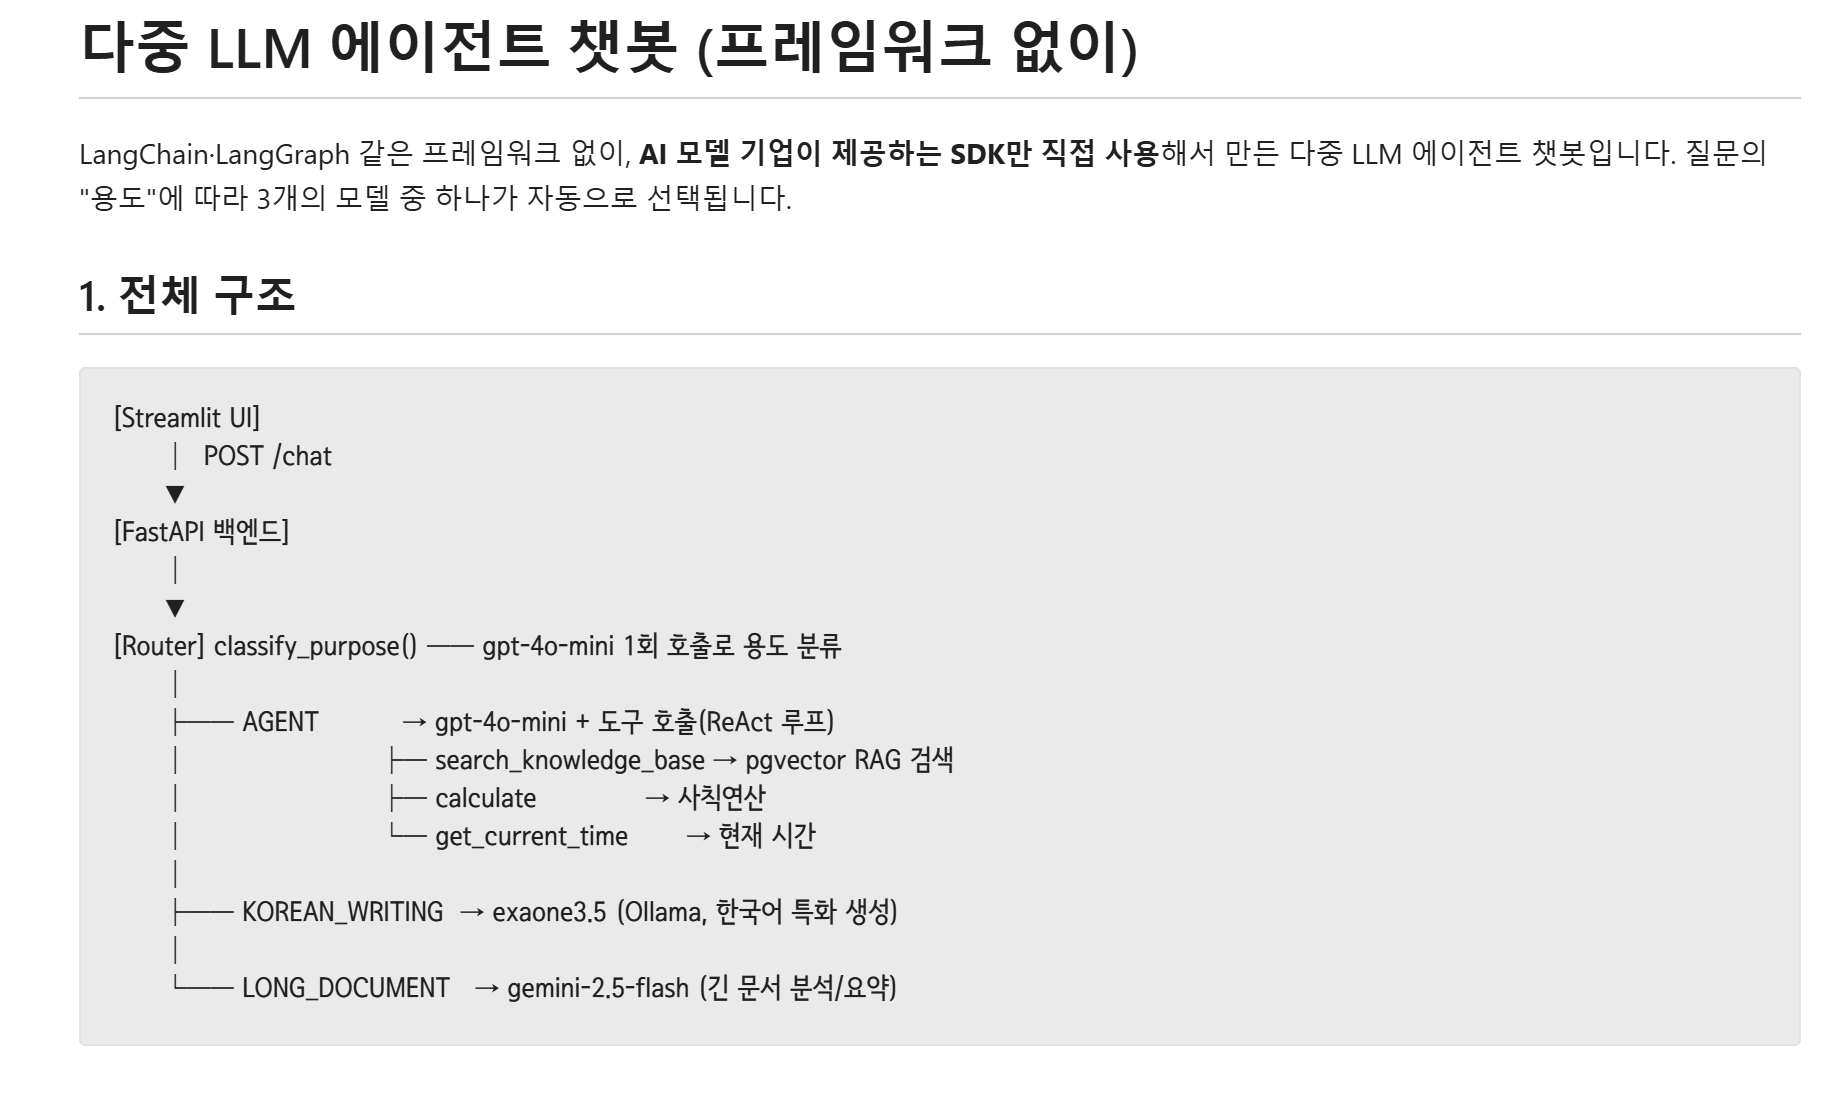

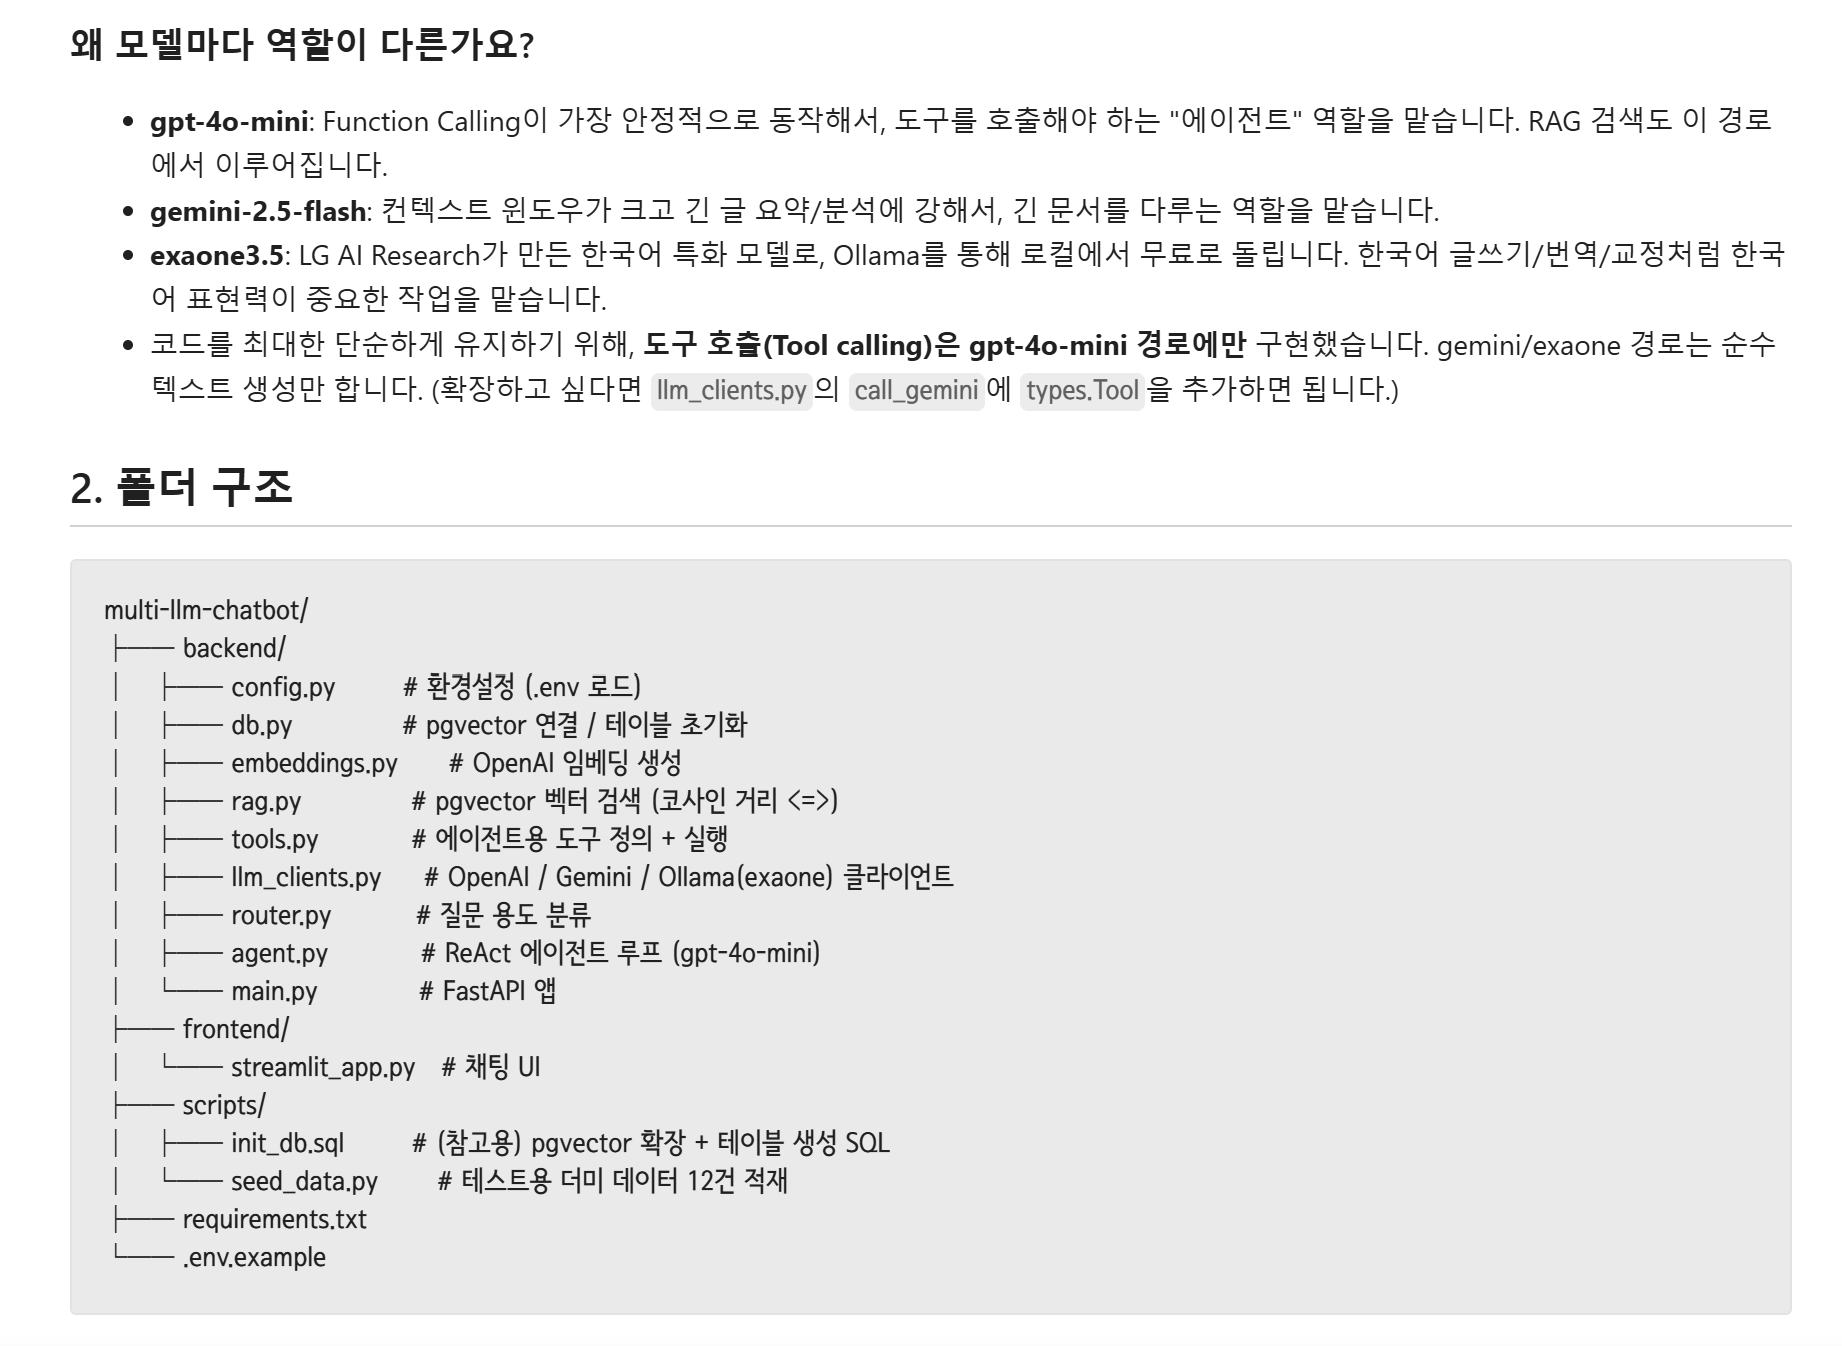

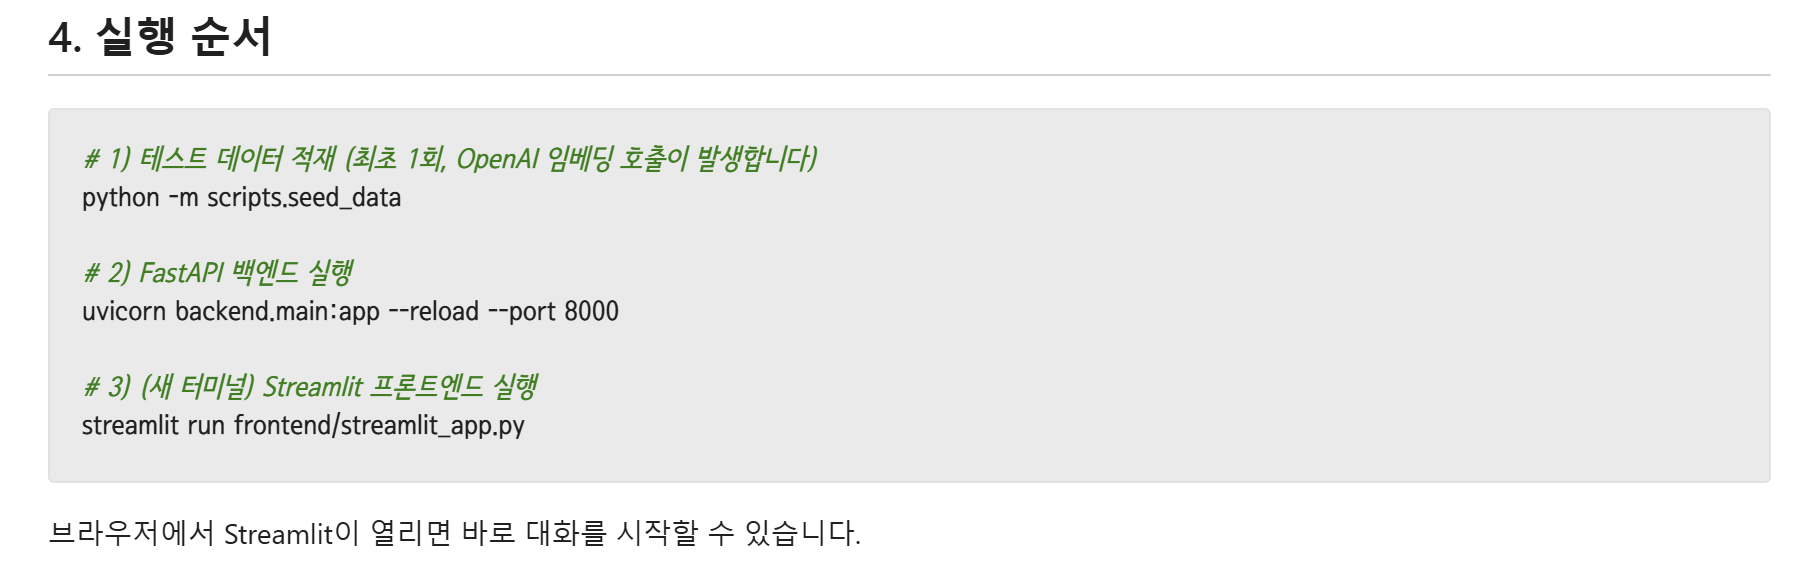

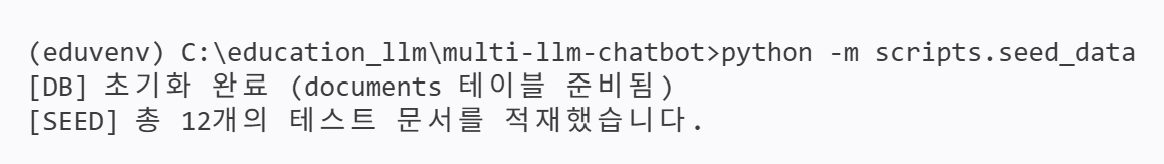

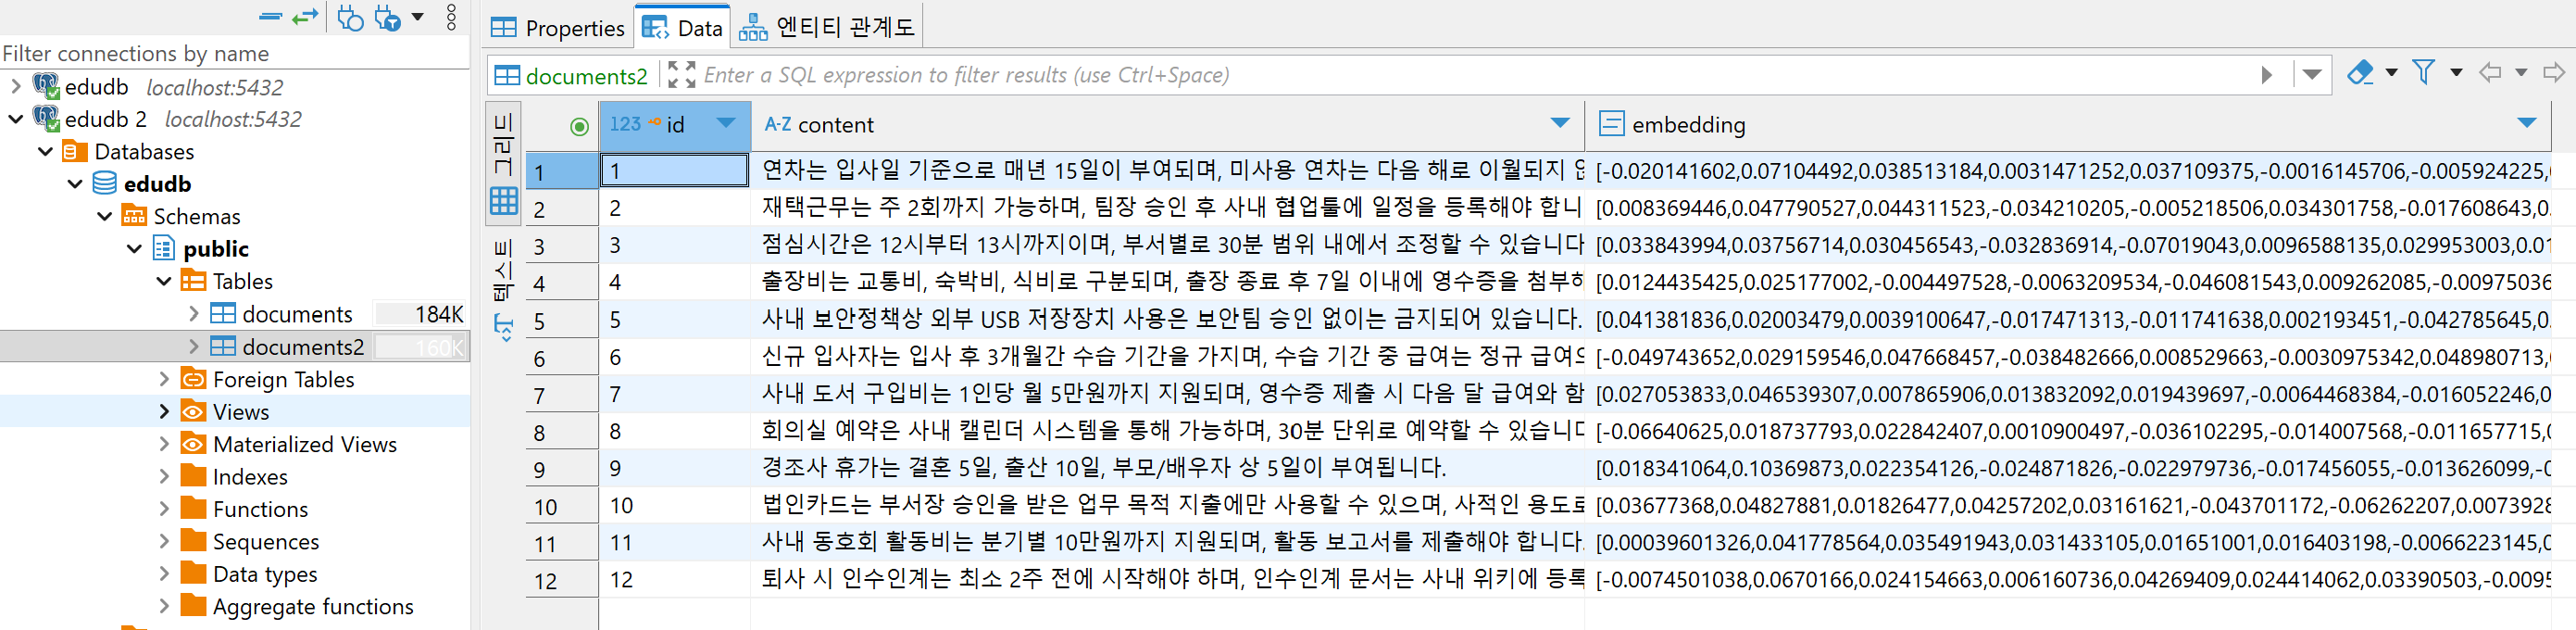

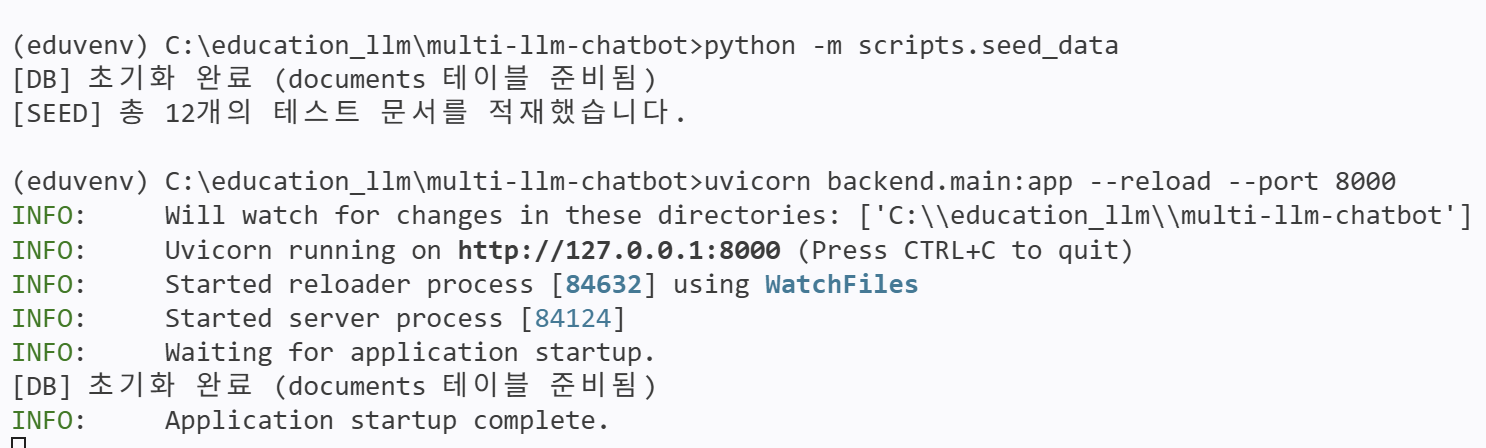

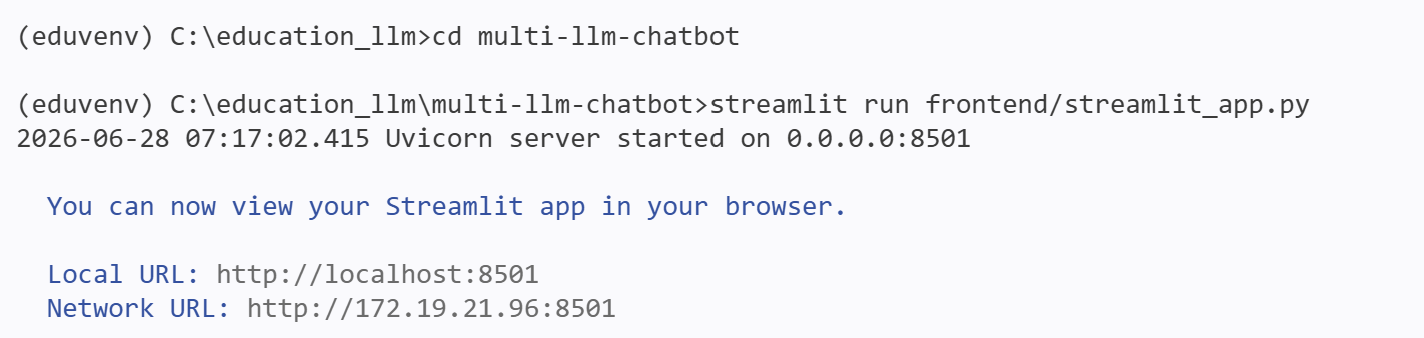

- AGENT: 일반적인 질문, 회사 지식베이스(FAQ/정책) 검색이 필요한 질문, 계산, 시간 조회 등
         도구(tool) 사용이 필요할 수 있는 모든 질문 (기본값)
- KOREAN_WRITING: 한국어 창작, 번역, 글쓰기 톤 변경, 한국어 요약/교정 등
                  한국어 표현력이 중요한 작업
- LONG_DOCUMENT: 사용자가 붙여넣은 긴 텍스트/문서를 분석, 요약, 정리해달라는 작업

### <span style='color:blue; font-weight:bold'>툴호출, 다중 LLM 활용 그리고 ReAct 대해 가볍게 학습했습니다.</span>